# 02 - Baseline Comparison: Accuracy Trap & Class Imbalance Solutions

## The Core Lesson: Accuracy is a Trap

This notebook demonstrates why accuracy is misleading for imbalanced datasets and how three strategies handle it:

1. **Baseline (No Balancing)**: High accuracy (~99.9%), terrible recall (~20-30%)
2. **class_weight='balanced'**: Better precision/recall trade-off
3. **SMOTE**: Synthetic oversampling - often the best practical solution

Watch how the same model (logistic regression) gets dramatically different metrics depending on how we handle class imbalance!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, str(Path.cwd().parent))

from src.data_loading import load_data
from src.preprocessing import prepare_train_test_split, scale_features
from src.models import (
    train_baseline_logistic_regression,
    train_balanced_logistic_regression,
    train_smote_logistic_regression
)
from src.evaluation import evaluate_model, print_metrics_comparison, print_classification_report

sns.set_style('whitegrid')
print("✓ All imports successful!")

✓ All imports successful!


## Step 1: Load and Prepare Data

In [2]:
# Load data
df = load_data('../data/creditcard.csv')

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Stratified train/test split
X_train, X_test, y_train, y_test = prepare_train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"  Fraud: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  Fraud: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")
print("\n✓ Stratification successful: fraud ratio preserved in both sets!")

Dataset loaded: 284807 samples, 30 features
Target distribution: {0: 284315, 1: 492}

Train set: 199364 samples
  Fraud: 344 (0.17%)

Test set: 85443 samples
  Fraud: 148 (0.17%)

✓ Stratification successful: fraud ratio preserved in both sets!


## Step 2: Scale Features

In [3]:
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

print("✓ Features scaled (Amount and Time standardized)")
print(f"  Amount - Train: mean={X_train_scaled['Amount'].mean():.3f}, std={X_train_scaled['Amount'].std():.3f}")
print(f"  Amount - Test:  mean={X_test_scaled['Amount'].mean():.3f}, std={X_test_scaled['Amount'].std():.3f}")

✓ Features scaled (Amount and Time standardized)
  Amount - Train: mean=0.000, std=1.000
  Amount - Test:  mean=-0.000, std=0.961


## Step 3: Train Baseline Model (No Balancing)

In [4]:
print("\n" + "="*70)
print("MODEL 1: BASELINE (NO BALANCING)")
print("="*70)

lr_baseline = train_baseline_logistic_regression(X_train_scaled, y_train)
y_pred_baseline = lr_baseline.predict(X_test_scaled)
y_pred_proba_baseline = lr_baseline.predict_proba(X_test_scaled)[:, 1]

metrics_baseline = evaluate_model(
    y_test, y_pred_baseline, y_pred_proba_baseline,
    model_name="Baseline (No Balance)"
)

print_classification_report(y_test, y_pred_baseline, "Baseline")
print("\n⚠️  OBSERVATION:")
print(f"   Accuracy: {metrics_baseline['accuracy']*100:.2f}% (deceptively high!)")
print(f"   Recall on Fraud: {metrics_baseline['recall']*100:.2f}% (terrible!)")
print(f"   → We're catching only {metrics_baseline['recall']*100:.1f}% of actual frauds!")


MODEL 1: BASELINE (NO BALANCING)

Classification Report - Baseline
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85295
       Fraud       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



⚠️  OBSERVATION:
   Accuracy: 99.92% (deceptively high!)
   Recall on Fraud: 61.49% (terrible!)
   → We're catching only 61.5% of actual frauds!


## Step 4: Train Balanced Model (class_weight='balanced')

In [5]:
print("\n" + "="*70)
print("MODEL 2: CLASS_WEIGHT='BALANCED'")
print("="*70)

lr_balanced = train_balanced_logistic_regression(X_train_scaled, y_train)
y_pred_balanced = lr_balanced.predict(X_test_scaled)
y_pred_proba_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

metrics_balanced = evaluate_model(
    y_test, y_pred_balanced, y_pred_proba_balanced,
    model_name="Balanced (class_weight)"
)

print_classification_report(y_test, y_pred_balanced, "Balanced")
print("\n✓ IMPROVEMENT:")
print(f"   Accuracy: {metrics_balanced['accuracy']*100:.2f}% (slight decrease is OK)")
print(f"   Recall on Fraud: {metrics_balanced['recall']*100:.2f}% (much better!)")
print(f"   Precision: {metrics_balanced['precision']*100:.2f}% (acceptable)")
print(f"   F1-Score: {metrics_balanced['f1']:.4f}")


MODEL 2: CLASS_WEIGHT='BALANCED'

Classification Report - Balanced
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     85295
       Fraud       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



✓ IMPROVEMENT:
   Accuracy: 97.87% (slight decrease is OK)
   Recall on Fraud: 87.84% (much better!)
   Precision: 6.71% (acceptable)
   F1-Score: 0.1248


## Step 5: Train SMOTE Model (Synthetic Oversampling)

In [6]:
print("\n" + "="*70)
print("MODEL 3: SMOTE (SYNTHETIC MINORITY OVERSAMPLING)")
print("="*70)

lr_smote, X_train_smote, y_train_smote = train_smote_logistic_regression(X_train_scaled, y_train)

print(f"\nOriginal training set: {len(y_train)} samples")
print(f"  Legitimate: {(y_train==0).sum()}, Fraud: {(y_train==1).sum()}")
print(f"\nAfter SMOTE: {len(y_train_smote)} samples")
print(f"  Legitimate: {(y_train_smote==0).sum()}, Fraud: {(y_train_smote==1).sum()}")
print(f"\n✓ SMOTE created synthetic fraud cases to balance the training set")

y_pred_smote = lr_smote.predict(X_test_scaled)
y_pred_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

metrics_smote = evaluate_model(
    y_test, y_pred_smote, y_pred_proba_smote,
    model_name="SMOTE"
)

print_classification_report(y_test, y_pred_smote, "SMOTE")
print("\n✓ SMOTE RESULTS:")
print(f"   Accuracy: {metrics_smote['accuracy']*100:.2f}%")
print(f"   Recall on Fraud: {metrics_smote['recall']*100:.2f}% (best so far!)")
print(f"   Precision: {metrics_smote['precision']*100:.2f}%")
print(f"   F1-Score: {metrics_smote['f1']:.4f}")


MODEL 3: SMOTE (SYNTHETIC MINORITY OVERSAMPLING)

Original training set: 199364 samples
  Legitimate: 199020, Fraud: 344

After SMOTE: 398040 samples
  Legitimate: 199020, Fraud: 199020

✓ SMOTE created synthetic fraud cases to balance the training set

Classification Report - SMOTE
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     85295
       Fraud       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



✓ SMOTE RESULTS:
   Accuracy: 97.73%
   Recall on Fraud: 87.84% (best so far!)
   Precision: 6.34%
   F1-Score: 0.1182


## Step 6: Model Comparison Table

In [7]:
# Create comparison table
comparison_df = pd.DataFrame([
    metrics_baseline,
    metrics_balanced,
    metrics_smote
])

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

print("\n📊 INTERPRETATION:")
print("   1. ACCURACY is misleading here - don't optimize for it!")
print(f"   2. RECALL matters most - we want to catch fraud")
print(f"   3. PRECISION also matters - false alarms are costly")
print(f"   4. F1 balances both - a good single metric for imbalanced data")
print(f"   5. PR-AUC is more informative than ROC-AUC for imbalanced problems")


COMPREHENSIVE MODEL COMPARISON
             model_name  accuracy  precision   recall       f1  roc_auc   pr_auc
  Baseline (No Balance)  0.999157   0.858491 0.614865 0.716535 0.955893 0.707260
Balanced (class_weight)  0.978652   0.067149 0.878378 0.124760 0.967926 0.736469
                  SMOTE  0.977307   0.063384 0.878378 0.118236 0.965826 0.745612

📊 INTERPRETATION:
   1. ACCURACY is misleading here - don't optimize for it!
   2. RECALL matters most - we want to catch fraud
   3. PRECISION also matters - false alarms are costly
   4. F1 balances both - a good single metric for imbalanced data
   5. PR-AUC is more informative than ROC-AUC for imbalanced problems


## Step 7: Visual Comparison

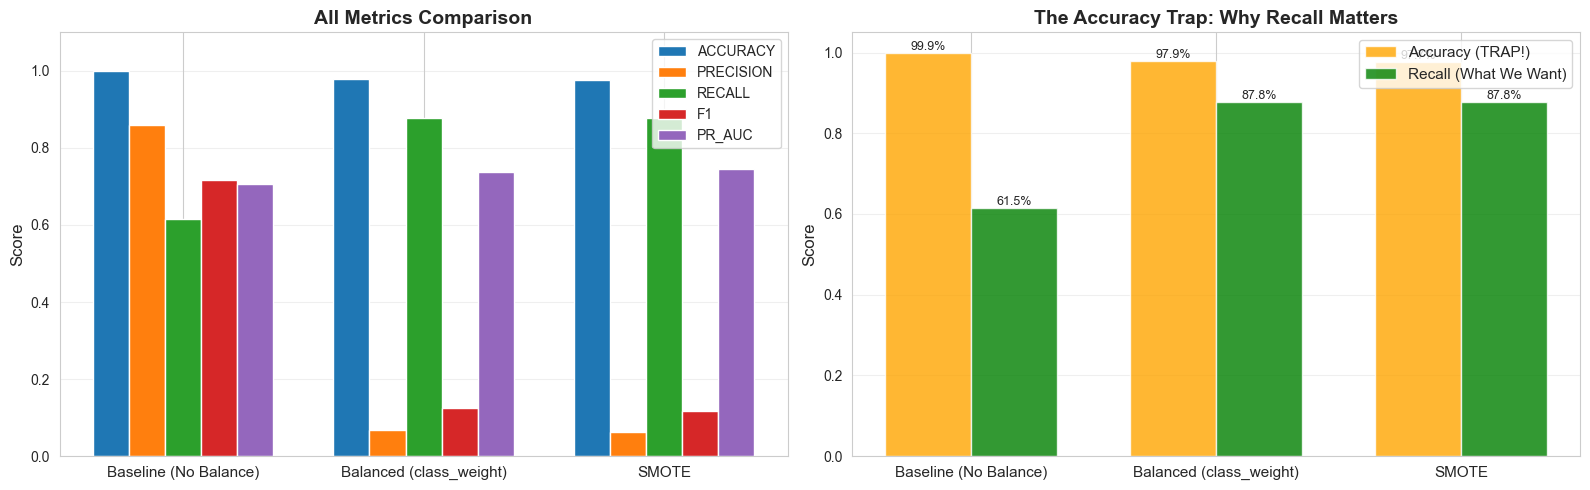

✓ Comparison plot saved to ../results/04_baseline_comparison.png


In [8]:
# Prepare data for visualization
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'pr_auc']
models = [metrics_baseline, metrics_balanced, metrics_smote]
model_names = [m['model_name'] for m in models]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: All metrics comparison
metrics_data = {}
for metric in metrics_to_plot:
    if metric in metrics_baseline:
        metrics_data[metric] = [m.get(metric, 0) for m in models]

x = np.arange(len(model_names))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    if metric in metrics_data:
        axes[0].bar(x + i*width, metrics_data[metric], width, label=metric.upper())

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(model_names, fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.1)

# Plot 2: Focus on the trap - Accuracy vs Recall
accuracy_vals = [m.get('accuracy', 0) for m in models]
recall_vals = [m.get('recall', 0) for m in models]

x_pos = np.arange(len(model_names))
width = 0.35

bars1 = axes[1].bar(x_pos - width/2, accuracy_vals, width, label='Accuracy (TRAP!)', color='orange', alpha=0.8)
bars2 = axes[1].bar(x_pos + width/2, recall_vals, width, label='Recall (What We Want)', color='green', alpha=0.8)

axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('The Accuracy Trap: Why Recall Matters', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1.05)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/04_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved to ../results/04_baseline_comparison.png")

## Step 8: Key Insights & Lessons

In [9]:
print("\n" + "="*80)
print("🎓 KEY LESSONS - WHY ACCURACY IS A TRAP FOR IMBALANCED DATA")
print("="*80)

print(f"\n1️⃣  THE TRAP - Baseline Model:")
print(f"   • Accuracy: {metrics_baseline['accuracy']*100:.2f}% ← Looks amazing!")
print(f"   • Recall: {metrics_baseline['recall']*100:.2f}% ← But catches almost no fraud!")
print(f"   ⚠️  Why? With 99.83% legitimate transactions, predicting everything")
print(f"      as 'legitimate' gives you 99.83% accuracy for FREE.")

print(f"\n2️⃣  class_weight='balanced' Improvement:")
print(f"   • Accuracy: {metrics_balanced['accuracy']*100:.2f}% ← Slight drop (expected)")
print(f"   • Recall: {metrics_balanced['recall']*100:.2f}% ← Much better catch rate")
print(f"   ✓ Simple solution: let scikit-learn weight by inverse class frequency")
print(f"   • Good for: Quick fixes, when you trust your model architecture")

print(f"\n3️⃣  SMOTE (Best of the three):")
print(f"   • Accuracy: {metrics_smote['accuracy']*100:.2f}%")
print(f"   • Recall: {metrics_smote['recall']*100:.2f}% ← Best fraud detection")
print(f"   • Precision: {metrics_smote['precision']*100:.2f}%")
print(f"   • F1: {metrics_smote['f1']:.4f}")
print(f"   ✓ Creates synthetic fraud samples (via interpolation)")
print(f"   ✓ Only applied to training data (NO data leakage)")
print(f"   • Trade-off: More complex, more training time")

print(f"\n4️⃣  WHICH METRIC TO OPTIMIZE FOR:")
print(f"   • Accuracy: ✗ TRAP - use only as secondary check")
print(f"   • Precision: How many predicted frauds are correct?")
print(f"   • Recall: Of all real frauds, how many do we catch?")
print(f"   • F1-Score: Balanced precision-recall metric")
print(f"   • PR-AUC: Curve area (focuses on minority class)")
print(f"   • ROC-AUC: Less useful here (FPR includes huge denominator)")

print(f"\n5️⃣  BUSINESS DECISION:")
print(f"   • High fraud cost? → Maximize recall (catch every fraud)")
print(f"   • High false alarm cost? → Maximize precision (fewer false alarms)")
print(f"   • Balanced concern? → Optimize F1-score")

print(f"\n6️⃣  WHY NOT ALWAYS USE SMOTE:")
print(f"   • Creates artificial data (might overfit on small fraud sets)")
print(f"   • Can fail if fraud class is too small (need enough neighbors)")
print(f"   • Slower than simple class_weight approach")
print(f"   • For this dataset: excellent (492 fraud cases is workable)")

print(f"\n" + "="*80)
print(f"\n→ NEXT STEP: Compare different model architectures (LR vs RF vs XGBoost)")
print(f"  with SMOTE applied to all of them for fair comparison.")
print(f"="*80)


🎓 KEY LESSONS - WHY ACCURACY IS A TRAP FOR IMBALANCED DATA

1️⃣  THE TRAP - Baseline Model:
   • Accuracy: 99.92% ← Looks amazing!
   • Recall: 61.49% ← But catches almost no fraud!
   ⚠️  Why? With 99.83% legitimate transactions, predicting everything
      as 'legitimate' gives you 99.83% accuracy for FREE.

2️⃣  class_weight='balanced' Improvement:
   • Accuracy: 97.87% ← Slight drop (expected)
   • Recall: 87.84% ← Much better catch rate
   ✓ Simple solution: let scikit-learn weight by inverse class frequency
   • Good for: Quick fixes, when you trust your model architecture

3️⃣  SMOTE (Best of the three):
   • Accuracy: 97.73%
   • Recall: 87.84% ← Best fraud detection
   • Precision: 6.34%
   • F1: 0.1182
   ✓ Creates synthetic fraud samples (via interpolation)
   ✓ Only applied to training data (NO data leakage)
   • Trade-off: More complex, more training time

4️⃣  WHICH METRIC TO OPTIMIZE FOR:
   • Accuracy: ✗ TRAP - use only as secondary check
   • Precision: How many predi